# **Loan Default prediction for banks**
1) Executive summary

This research project tries to solve the problem of loan default prediction of a digital lending company based on a dataset of 255,347 loans. The key factors of risks identified using the exploratory analysis encompass high interest rates, low income, and unemployment. Three machine learning models such as Logistic Regression, Random Forest, and Gradient Boosting have been trained and tested and the Gradient Boosting proved to have the optimum combination of accuracy and ROC-AUC. The suggestions that are applicable to the case of the proposed business are the followings besides the implementation of the chosen model that pre-approves scoring, the use of conservative borrowing threshold to identify a high-risk applicant, and co-signer/collateral proposal when dealing with the risky profiles. This method will improve risk-taking, minimize anticipate losses, and help to take lending decisions based on the data.

2) Business context, Aim & Objectives

2.1 Business Context

The client considered in this case study is a digital lending Fintech company which provides unsecured and small ticket loans to customers, retail consumers. As the company grows aggressively, their two major problems are getting credit available to as many clients as possible and minimizing their financial losses caused by defaults to a minimal. The fundamental risk management approach in predictive analytics is risk provisioning, utilizing credit policy formulation, and offering customers with custom loan terms including interest rate payment and co-signer waivers or flexible loan repayment. Otherwise, based on its deficient data-driven approach, lending decisions may cause inconsistency, and the firm may purchase large numbers of non-performing assets and compromise its profitability.

2.2 Aim:

The key goals of the present research is to develop an explanatory data come in to descriptions of the risk of defaults in loans and to receive suggestion to make more confident lending choices.

2.3 Objectives:

To carry out EDA (exploratory data analysis) to determine the relevant patterns, relationships and risk factors in facility loan data.

To progressively and systematically preprocess data and create features using data quality engineering.

To model and calibrate predictive models for rating default probability.

To ensure Interpretability by identifying the Most Influential Predictors of Default

To deliver a repeatable/documented framework to support data data-driven methodology for credit strategy.

3) Data source & Dataset description

Loan Default (Loan_default.csv) [Source code:/URL: https://www.kaggle.com/datasets/nikhil1e9/loan-default ]

The source data is loan default data obtained from Kaggle over the internet. It contains 255,347 rows and 18 columns. Key numeric variables: Age, Income, LoanAmount, InterestRate, CreditScore, MonthsEmployed, NumCreditLines, DTIRatio, Education, EmploymentType, MaritalStatus, HasMortgage, HasDependents, LoanPurpose, and HasCoSigner are all categorical. The dependent variable (Default) is 0 (not default) and 1 (default). The data is considered particularly moderately imbalanced (with ~12% defaults). An ID column (LoanID) is available and will not be analysed.

4) Business questions at a glance

Business Question(s) One Page Summary

The data analysis is applied to various business questions seeking to identify risk drivers and lending strategy. Each question is addressed as a subdivision of the notebook and coded with explanation and insights.

Which is the most important predicted variable that is associated with default?
How does default rate break out by EmploymentType, MaritalStatus, and/or HasCoSigner?
How does default differ by Income, Age, and CreditScore quantiles?
Does an increase in default probability correlate with an increase in InterestRate?
What is the most appropriate operating point for identifying risky loans for future intervention?
What are the losses that are projected (LoanAmount X default_rate)?
Does the model performance work over cohorts/time slices?

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder,LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,
                             classification_report,roc_curve,roc_auc_score)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
import joblib
import shap

In [ ]:
# ---- 2) Load dataset ----
DATA_PATH = "Loan_default.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [ ]:
# Clean column names
df.columns = [c.strip().replace(" ", "_").replace(".", "_") for c in df.columns]

In [ ]:
df.columns


Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

In [ ]:

print("First few rows:",df.head())
print("\n shape: \n",df.shape)
print("--------------------------------")
print("\n Columne Names: \n", df.columns)
print("--------------------------------")
print("\n Info:\n ", df.info())
print("--------------------------------")
print("\n Stats:\n ", df.describe())
print("--------------------------------")
print("\n Missing column count:\n ", df.isnull().sum())
print("--------------------------------")

First few rows:        LoanID  Age  Income  LoanAmount  CreditScore  MonthsEmployed  \
0  I38PQUQS96   56   85994       50587          520              80   
1  HPSK72WA7R   69   50432      124440          458              15   
2  C1OZ6DPJ8Y   46   84208      129188          451              26   
3  V2KKSFM3UN   32   31713       44799          743               0   
4  EY08JDHTZP   60   20437        9139          633               8   

   NumCreditLines  InterestRate  LoanTerm  DTIRatio    Education  \
0               4         15.23        36      0.44   Bachelor's   
1               1          4.81        60      0.68     Master's   
2               3         21.17        24      0.31     Master's   
3               3          7.07        24      0.23  High School   
4               4          6.51        48      0.73   Bachelor's   

  EmploymentType MaritalStatus HasMortgage HasDependents LoanPurpose  \
0      Full-time      Divorced         Yes           Yes       Other   
1   

In [ ]:
# ---- 3) Detect target column ----
possible_targets = ['default', 'loan_default', 'is_default', 'bad_loan', 'target', 'loan_status']
target = None
for t in possible_targets:
    for col in df.columns:
        if col.lower() == t.lower():
            target = col
            break
    if target: break

# fallback if still not found
if target is None:
    for col in df.columns[::-1]:
        if df[col].nunique() == 2:
            target = col
            break

print("Target column detected:", target)

Target column detected: Default


 Explanation: Target column Default was identified, coded (0/1). The frequency was divided into numeric (9 variables) and categorical (7 variables), with items not having an identifier, properly preprocessed to be fitted in the modeling.





**Exploratory Data Analysis (EDA)**

InterestRate and LoanAmount have a positive relationship with the defaults and Age, Income and Employment stability, on the other hand, mitigate the risk through EDA. Categorical analysis shows that more people default who are not employed, divorced, do not have dependents or co-signers, therefore showing demographics and financial aspects to be an incentive to default on loans.



In [ ]:
# ---- 4) Encode target as 0/1 ----
if df[target].dtype == object:
    le = LabelEncoder()
    df[target] = le.fit_transform(df[target].astype(str))
print("Target distribution:\n", df[target].value_counts(normalize=True))

Target distribution:
 Default
0    0.883872
1    0.116128
Name: proportion, dtype: float64


In [ ]:
# ---- 5) Separate numeric and categorical ----
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
# remove target and ID-like columns
if target in numeric_cols:
  numeric_cols.remove(target)
if target in categorical_cols:
  categorical_cols.remove(target)
categorical_cols = [c for c in categorical_cols if "id" not in c.lower()]
print("Numeric features:", numeric_cols)
print("Categorical features:", categorical_cols)

Numeric features: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']
Categorical features: ['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


In [ ]:
# ---- 6) EDA ----
print("\n--- Correlation with Default ---")
print(df[numeric_cols + [target]].corr()[target].sort_values(ascending=False))
# Categorical default rates
for c in categorical_cols:
    print("\nDefault rates by",c)
    print(df.groupby(c)[target].mean().round(3))


--- Correlation with Default ---
Default           1.000000
InterestRate      0.131273
LoanAmount        0.086659
NumCreditLines    0.028330
DTIRatio          0.019236
LoanTerm          0.000545
CreditScore      -0.034166
MonthsEmployed   -0.097374
Income           -0.099119
Age              -0.167783
Name: Default, dtype: float64

Default rates by Education
Education
Bachelor's     0.121
High School    0.129
Master's       0.109
PhD            0.106
Name: Default, dtype: float64

Default rates by EmploymentType
EmploymentType
Full-time        0.095
Part-time        0.120
Self-employed    0.115
Unemployed       0.136
Name: Default, dtype: float64

Default rates by MaritalStatus
MaritalStatus
Divorced    0.125
Married     0.104
Single      0.119
Name: Default, dtype: float64

Default rates by HasMortgage
HasMortgage
No     0.123
Yes    0.109
Name: Default, dtype: float64

Default rates by HasDependents
HasDependents
No     0.127
Yes    0.105
Name: Default, dtype: float64

Default rates

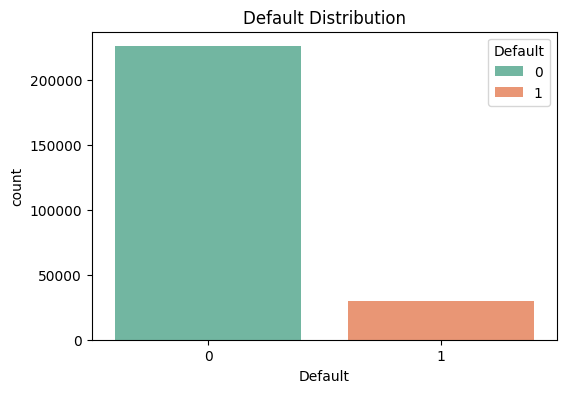

In [ ]:
# =====================================================
#              🔎 EXPLORATORY DATA ANALYSIS
# =====================================================

# --- A) Default rate distribution ---
plt.figure(figsize=(6,4))
sns.countplot(x=target, data=df, hue=target,palette="Set2")
plt.title("Default Distribution")
plt.show()

Explanation: The graphical representation of the Default Distribution, tells about the proportion of loans that are not in default (non-defaults, 0) and the ones that are (1) and that such distribution is moderate (not too imbalanced, approximately).

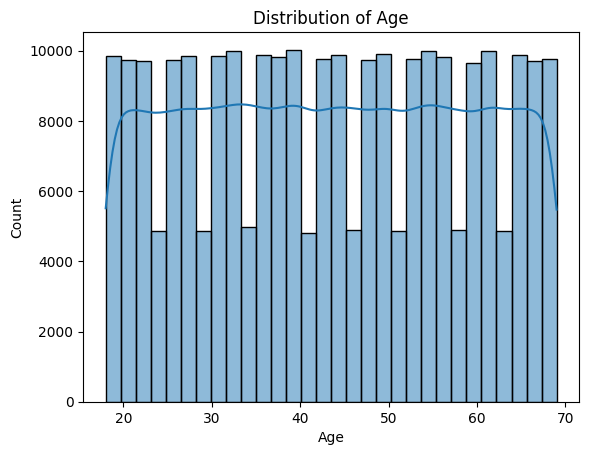

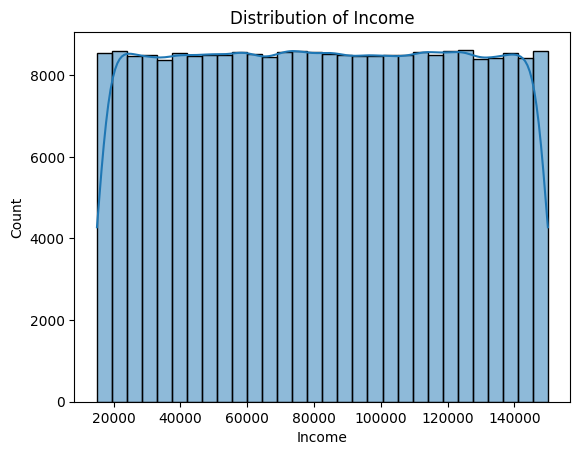

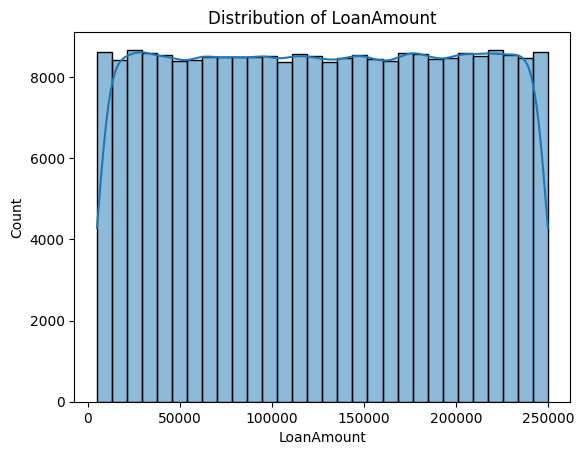

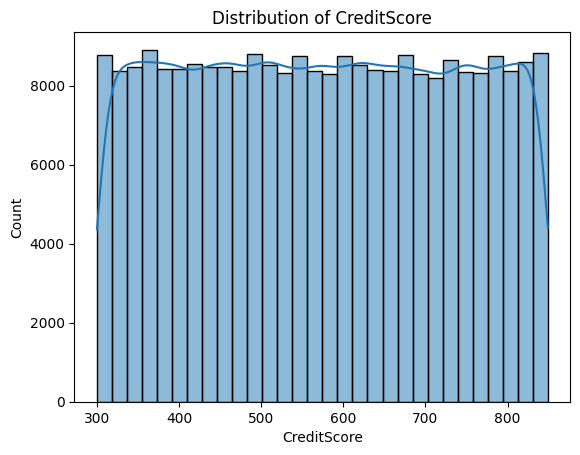

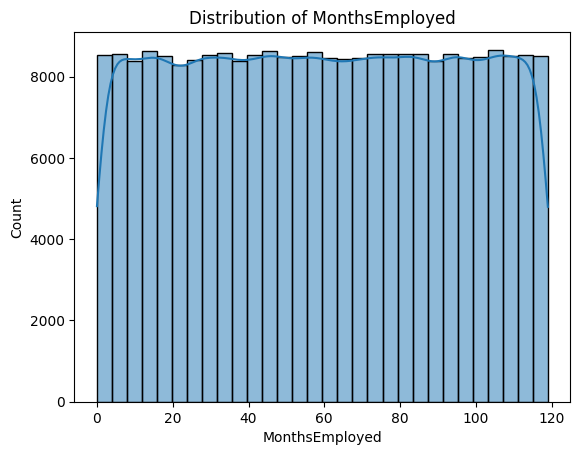

In [ ]:
# --- B) Numeric distributions ---
for col in numeric_cols[:5]:  # show first 5
    plt.figure()
    sns.histplot(df[col], kde=True, bins=30)
    plt.title("Distribution of {}".format(col))
    plt.show()

Explanation: This code plots distributions of the first five numerical variablesAge, Income, LoanAmount, CreditScoreand MonthsEmployed with KDE overlays of histograms. The data dispersion, skewness and concentration are brought out through plots, and the different plots assist in establishing common borrower profile, extreme profile and characteristics of data that would be useful in the assessment process of a default risk.

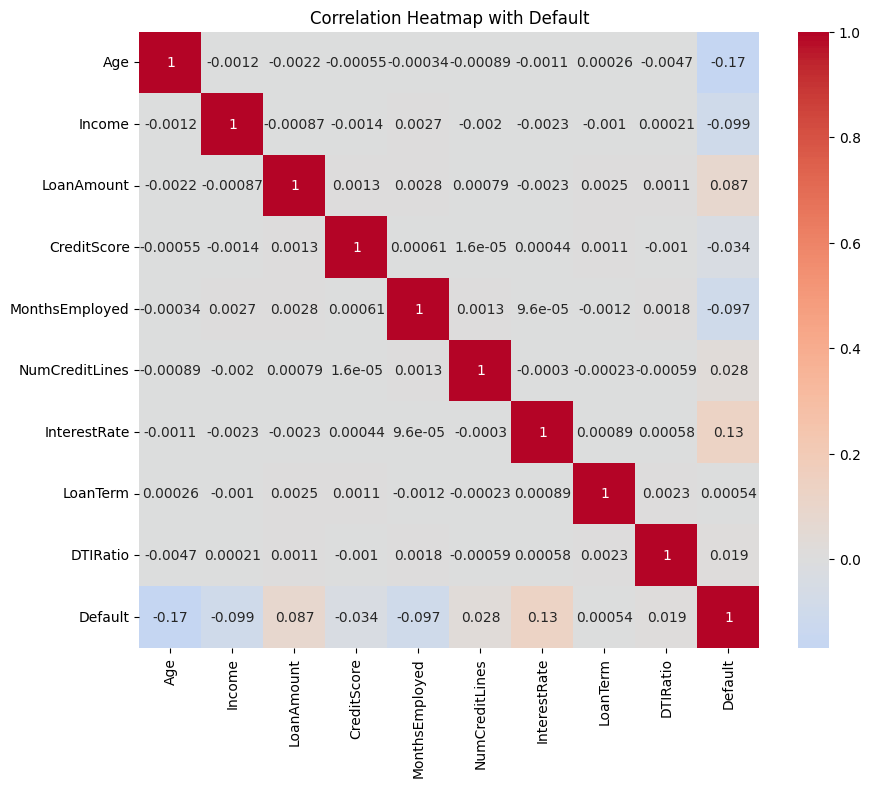

In [ ]:
# --- C) Correlation heatmap ---
plt.figure(figsize=(10,8))
corr = df[numeric_cols + [target]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap with Default")
plt.show()

Explanation: Such a code generates a heatmap of correlations between numeric features and the Default target. It graphically points towards the strength and direction of the relationships and is useful to determine which borrower characteristics (e.g., Age, InterestRate) have the greatest impact on the default risk.

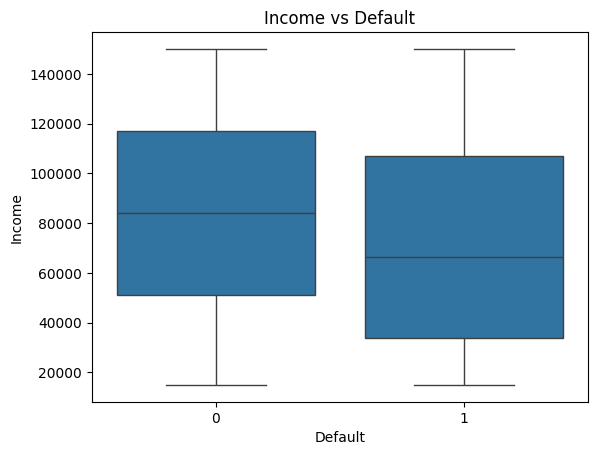

In [ ]:
# --- D) Boxplots: income vs default (if exists) ---
if "Income" in df.columns:
    plt.figure()
    sns.boxplot(x=target, y="Income", data=df)
    plt.title("Income vs Default")
    plt.show()

Explanation: According to this boxplot, it is a graph of Income verses Default, and it represents the distribution of income to defaulters and non-defaulters. Lesson: poorer borrowers will default a bit more and it ensures that income is a possible risk variable that would affect loan repayment.

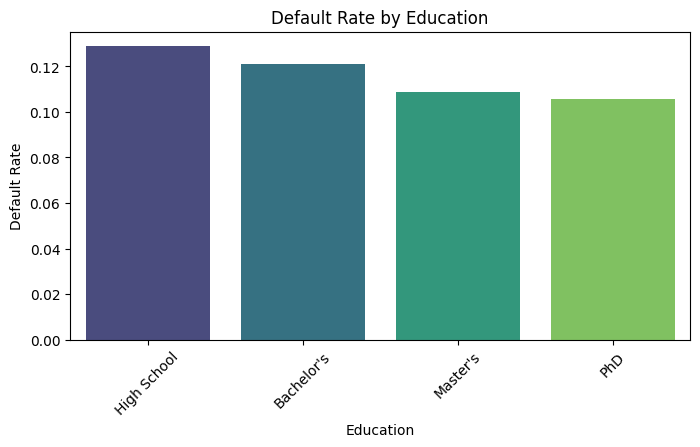

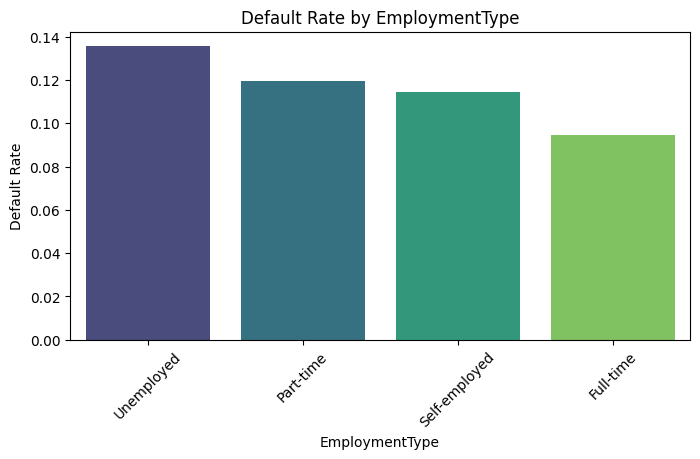

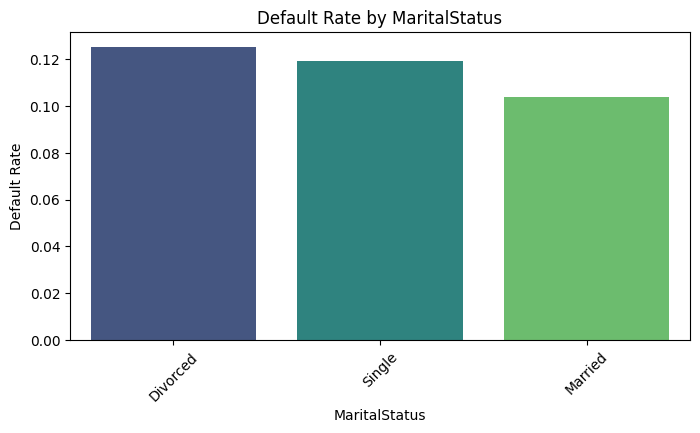

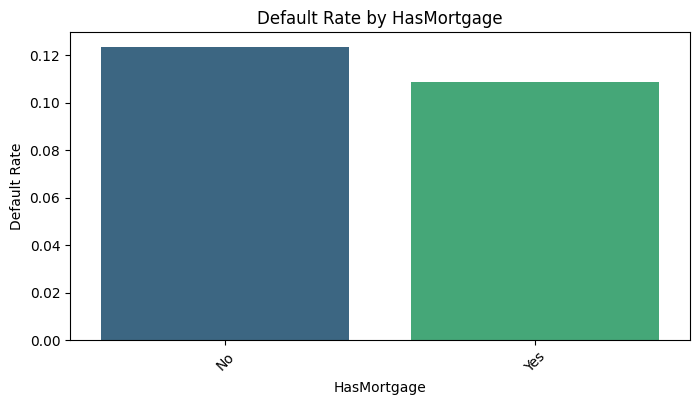

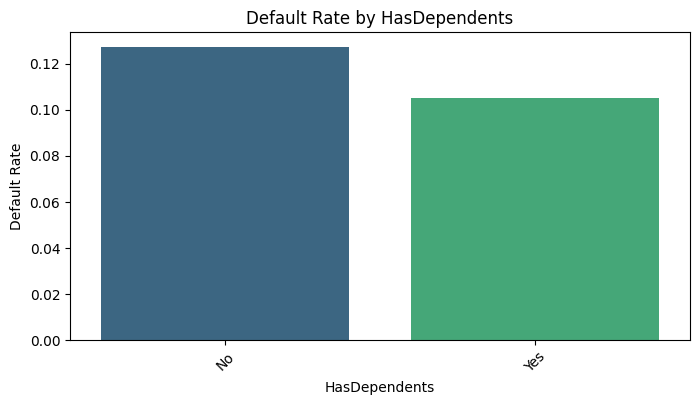

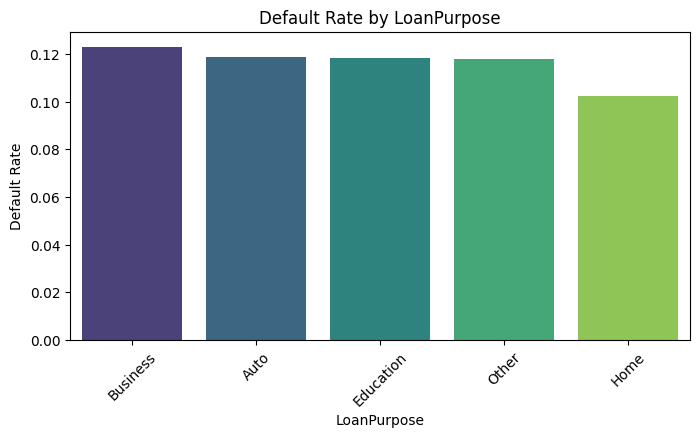

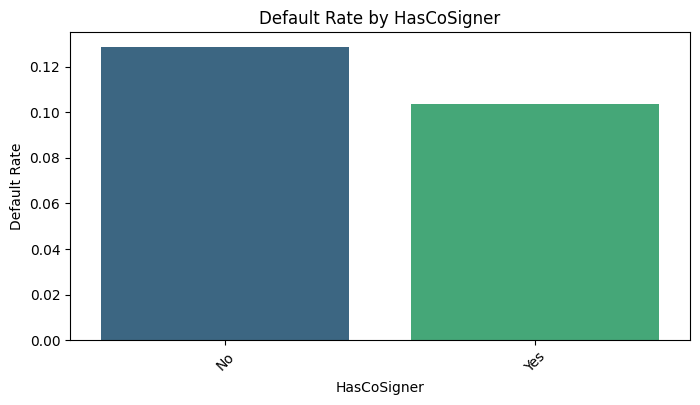

In [ ]:
# --- E) Categorical analysis: default rate by category ---
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    rate = df.groupby(col)[target].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index, y=rate.values, hue=rate.index,palette="viridis",legend=False)
    plt.title(f"Default Rate by {col}")
    plt.xticks(rotation=45)
    plt.ylabel("Default Rate")
    plt.show()

Explanation: This code produces bar graphs indicating the default rate of various features as categories. As an illustration, Unemployed, Divorced or those without a co-signer have higher default rates. Insight: the profile of the borrower, type of employment, marital status, mortgage, and number of dependents can determine the probability of the default risk, and this information will act upon cues of specific credit policies and risk assessment.

In [ ]:
# ---- 7) Prepare features ----
features = [c for c in df.columns if c != target]
x = df[features]
y = df[target]

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, stratify=y, test_size=0.2, random_state=42
)

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))  # ✅ fixed
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

Explanation: It is also covered with preparation that is required in modeling data into train and test sets, and pipelines: numeric features are imputed and scaled, categorical features imputed and one-hot coded, to predict default correctly.

In [ ]:
# ---- 8) Define models ----
#Logistic Regression is used as the first model because it serves as a strong baseline for binary classification problems.
log_pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("clf", LogisticRegression(max_iter=1000))])



Logistic Regression is used as the first model because it serves as a strong baseline for binary classification problems

In [ ]:

param_grid = {
    "clf__C": [0.01, 0.1, 1, 10]
}
grid = GridSearchCV(
    estimator=log_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Income',
                                                                          'LoanAmount',
                                                                          'CreditScore',
                                                                          'MonthsEmployed',
                                                                          'NumCreditLines',
                                                                          'InterestRate',
                                                                          'LoanTerm',
                                                                          'DTIRatio']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(fill_value='Missing',
                                                                                                        strategy='constant')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['Education',
                                                                          'EmploymentType',
                                                                          'MaritalStatus',
                                                                          'HasMortgage',
                                                                          'HasDependents',
                                                                          'LoanPurpose',
                                                                          'HasCoSigner'])])),
                                       ('clf',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1, param_grid={'clf__C': [0.01, 0.1, 1, 10]},
             scoring='f1')

In [ ]:

print("Best Parameters", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best Parameters {'clf__C': 1}
Best CV score: 0.06420837478028589


In [ ]:
best_model = grid.best_estimator_

y_train_pred = best_model.predict(x_train)
y_test_pred = best_model.predict(x_test)

In [ ]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
print("Train accuracy", train_acc)
print("Test accuracy", test_acc)

print("Precision", precision)
print("Recall", recall)
print("F1-score", f1)

Train accuracy 0.885102091767551
Test accuracy 0.885275112590562
Precision 0.608433734939759
Recall 0.03405833754847412
F1-score 0.06450582787801373



The training and testing accuracies are nearly identical (~88.5%), indicating that the model is not overfitting.

However, the high accuracy is misleading due to class imbalance. Since approximately 88% of loans are non-defaults, a model that predicts most cases as non-default can still achieve high accuracy without effectively identifying risky borrowers.


Although the model achieves a precision of 0.61 for the default class, the recall is extremely low (0.03).

This means the model identifies very few actual default cases. In other words, it correctly detects only about 3% of borrowers who will default.

The low recall leads to a very low F1-score, indicating poor performance in detecting risky borrowers.

In the context of loan risk prediction, recall is especially important because failing to detect a defaulting borrower can lead to financial losses.

In [ ]:
log_conf = confusion_matrix(y_test, y_test_pred)
log_classr = classification_report(y_test, y_test_pred)
print(log_conf)
print(log_classr)

[[45009   130]
 [ 5729   202]]
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.61      0.03      0.06      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.52      0.50     51070
weighted avg       0.85      0.89      0.84     51070




The confusion matrix shows that the model correctly predicts most non-default cases (45,009 true negatives).

However, it fails to detect a large number of default cases, resulting in 5,729 false negatives.

Only 202 default cases are correctly identified out of 5,931 actual defaults, which explains the extremely low recall score.

This behavior indicates that the model is biased toward predicting the majority class (non-default).


# **Update Baseline Pipeline for class_weight="balanced"**

In [ ]:
log_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
param_grid = {
    "clf__C":[0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    estimator=log_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(x_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV F1 score:", grid.best_score_)

best_model = grid.best_estimator_

y_train_pred = best_model.predict(x_train)
y_test_pred = best_model.predict(x_test)


train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Best parameters: {'clf__C': 10}
Best CV F1 score: 0.329965107667275
Train accuracy: 0.6753378990292593
Test accuracy: 0.6763853534364598
Precision: 0.21950444726810672
Recall: 0.6990389479008599
F1-score: 0.3340988758612353




The training and testing accuracies are very similar (~67.6%), indicating that the model generalizes well and is not overfitting.

However, the overall accuracy decreased compared to the previous Logistic Regression model (~88%). This decrease is expected because the model now prioritizes detecting the minority class (loan defaults) rather than maximizing overall accuracy.

**Precision, Recall, and F1-score**

After applying class weighting, the recall for the default class increased significantly from approximately 3% to about 70%.

This means the model is now able to correctly identify the majority of borrowers who will default. However, this improvement comes at the cost of lower precision (0.22), indicating that many borrowers predicted as defaults are actually non-default cases.

The F1-score improved compared to the previous model, reflecting a better balance between precision and recall.

In [ ]:
updated_log_conf = confusion_matrix(y_test, y_test_pred)
updated_log_classr = classification_report(y_test, y_test_pred)
print("------------------------------")
print("Old Report")
print(log_conf)
print(log_classr)
print("------------------------------")
print("New Report")
print(updated_log_conf)
print(updated_log_classr)

------------------------------
Old Report
[[45009   130]
 [ 5729   202]]
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45139
           1       0.61      0.03      0.06      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.52      0.50     51070
weighted avg       0.85      0.89      0.84     51070

------------------------------
New Report
[[30397 14742]
 [ 1785  4146]]
              precision    recall  f1-score   support

           0       0.94      0.67      0.79     45139
           1       0.22      0.70      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.68      0.73     51070




Confusion Matrix Analysis

The confusion matrix shows that the model now detects a much larger number of default cases.

Previously, the model correctly identified only a small fraction of defaults. After applying class weighting, the number of correctly detected default cases increased substantially.

However, this improvement results in a higher number of false positives, where some safe borrowers are incorrectly predicted as defaults. This tradeoff is common when optimizing models to better detect minority classes.

**Classification Report Insight**

The model now captures a much larger portion of default cases, achieving a recall of approximately 70% for the default class.

Although precision for defaults is relatively low, the improvement in recall is important for financial risk prediction, where failing to identify risky borrowers can lead to significant losses.

# **Compare with differnet Models,**

# Train and Predict all models

In [ ]:





models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced",random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "SVM": LinearSVC(class_weight="balanced"),
    "Naive Bayes":GaussianNB()
}
results = []
for name, model in models.items():
  pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
  pipeline.fit(x_train, y_train)

  y_train_pred = pipeline.predict(x_train)
  y_test_pred = pipeline.predict(x_test)

  train_acc = accuracy_score(y_train, y_train_pred)
  test_acc = accuracy_score(y_test, y_test_pred)
  precision = precision_score(y_test, y_test_pred)
  recall = recall_score(y_test, y_test_pred)
  f1 = f1_score(y_test, y_test_pred)
  roc_auc = roc_auc_score(y_test, y_test_pred)
  results.append({"Model": name, "Accuracy": test_acc, "Precision":precision, "Recall": recall, "F1": f1, "ROC AUC": roc_auc})
results_df = pd.DataFrame(results)
results_df.sort_values(by=["Recall", "F1","Accuracy"], ascending=False, inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,SVM,0.674741,0.219331,0.703591,0.334415,0.687271
1,Logistic Regression,0.676385,0.219504,0.699039,0.334099,0.686224
2,Decision Tree,0.817740,0.209330,0.205024,0.207155,0.551636
3,KNN,0.874036,0.315169,0.072163,0.117437,0.525780
4,Gradient Boosting,0.886705,0.608696,0.068454,0.123068,0.531336
5,Naive Bayes,0.884746,0.540835,0.050244,0.091947,0.522320
6,Random Forest,0.884825,0.699187,0.014500,0.028411,0.506840


In [ ]:
results_df

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,SVM,0.674741,0.219331,0.703591,0.334415,0.687271
1,Logistic Regression,0.676385,0.219504,0.699039,0.334099,0.686224
2,Decision Tree,0.817740,0.209330,0.205024,0.207155,0.551636
3,KNN,0.874036,0.315169,0.072163,0.117437,0.525780
4,Gradient Boosting,0.886705,0.608696,0.068454,0.123068,0.531336
5,Naive Bayes,0.884746,0.540835,0.050244,0.091947,0.522320
6,Random Forest,0.884825,0.699187,0.014500,0.028411,0.506840


# Choose Top 2 Models and Hyperparameter tune them

Tuning Logistic Regression

In [ ]:
log_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])


In [ ]:
log_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}
grid_log = GridSearchCV(
    estimator=log_pipeline,
    param_grid=log_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_log.fit(x_train, y_train)

print("Best parameters:", grid_log.best_params_)
print("Best CV F1 score:", grid_log.best_score_)

Best parameters: {'model__C': 10}
Best CV F1 score: 0.329965107667275


In [ ]:
# Best model
best_log_model = grid_log.best_estimator_

# Predictions
y_pred_log = best_log_model.predict(x_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_pred_log))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
log_tuned_conf = confusion_matrix(y_test, y_pred_log)
log_tuned_classr = classification_report(y_test, y_pred_log)
# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.6763853534364598
Precision: 0.21950444726810672
Recall: 0.6990389479008599
F1-score: 0.3340988758612353
ROC AUC: 0.686223875908825

Confusion Matrix:
 [[30397 14742]
 [ 1785  4146]]

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.67      0.79     45139
           1       0.22      0.70      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.68      0.73     51070



In [ ]:
print("-------------------------------------")
print("Before Hyperparameter Tuning")
print(updated_log_conf)
print(updated_log_classr)
print("-------------------------------------")
print("After Hyperparameter Tuning")
print(log_tuned_conf)
print(log_tuned_classr)

-------------------------------------
Before Hyperparameter Tuning
[[30397 14742]
 [ 1785  4146]]
              precision    recall  f1-score   support

           0       0.94      0.67      0.79     45139
           1       0.22      0.70      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.68      0.73     51070

-------------------------------------
After Hyperparameter Tuning
[[30397 14742]
 [ 1785  4146]]
              precision    recall  f1-score   support

           0       0.94      0.67      0.79     45139
           1       0.22      0.70      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.68      0.73     51070



No Improvement after tuning


SVM Tuning

In [ ]:
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearSVC(class_weight="balanced", max_iter=5000))
])

svm_param_grid = {
    "model__C": [0.01, 0.1, 1, 10]
}

grid_svm = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_svm.fit(x_train, y_train)

print("Best parameters:", grid_svm.best_params_)
print("Best CV F1 score:", grid_svm.best_score_)

Best parameters: {'model__C': 0.1}
Best CV F1 score: 0.32942018470772366


In [ ]:

best_svm_model = grid_svm.best_estimator_

y_pred_svm = best_svm_model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1-score:", f1_score(y_test, y_pred_svm))
print("ROC AUC:", roc_auc_score(y_test, y_pred_svm))

svm_conf = confusion_matrix(y_test, y_pred_svm)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

svm_classr = classification_report(y_test, y_pred_svm)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.6747405521832779
Precision: 0.21933144118574582
Recall: 0.7035912999494183
F1-score: 0.3344151941339103
ROC AUC: 0.6872705164981145

Confusion Matrix:
 [[30286 14853]
 [ 1758  4173]]

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.67      0.78     45139
           1       0.22      0.70      0.33      5931

    accuracy                           0.67     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.67      0.73     51070



In [ ]:

print("Before Tuning")
print("-----------------------------------------------")
print("Accuracy:",results_df[results_df["Model"] == "SVM"]["Accuracy"])
print("Precision:",results_df[results_df["Model"] == "SVM"]["Precision"])
print("Recall:",results_df[results_df["Model"] == "SVM"]["Recall"])
print("F1-score:",results_df[results_df["Model"] == "SVM"]["F1"])

print("-----------------------------------------------")
print("After Tuning")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1-score:", f1_score(y_test, y_pred_svm))

Before Tuning
-----------------------------------------------
Accuracy: 0    0.674741
Name: Accuracy, dtype: float64
Precision: 0    0.219331
Name: Precision, dtype: float64
Recall: 0    0.703591
Name: Recall, dtype: float64
F1-score: 0    0.334415
Name: F1, dtype: float64
-----------------------------------------------
After Tuning
Accuracy: 0.6747405521832779
Precision: 0.21933144118574582
Recall: 0.7035912999494183
F1-score: 0.3344151941339103



No Improvement

**ROC Curve - Linear SVM**

[-0.61482096 -0.75972116 -0.21110533 ... -0.11472337 -0.20948507
 -0.49216045]
ROC-AUC: 0.753213096328029


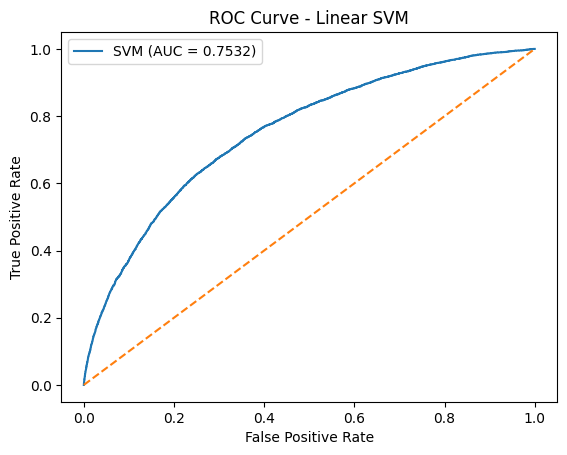

In [ ]:

# Get scores (not probabilities)
y_scores_svm = best_svm_model.decision_function(x_test)
print(y_scores_svm)
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores_svm)

# AUC score
roc_auc = roc_auc_score(y_test, y_scores_svm)

print("ROC-AUC:", roc_auc)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"SVM (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Linear SVM")
plt.legend()
plt.show()


The ROC-AUC score of approximately 0.75 indicates that the model has a good ability to distinguish between default and non-default cases.

This means that, on average, the model ranks a randomly chosen default case higher than a non-default case about 75% of the time.

[0.18626448 0.14006559 0.37846422 ... 0.43012372 0.37676274 0.23411964]
ROC-AUC: 0.753178373406614


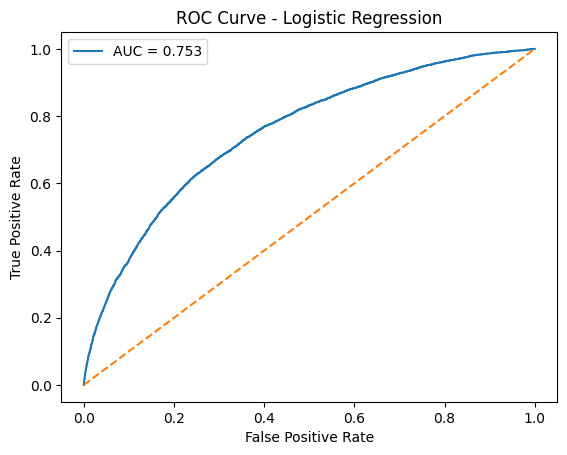

In [ ]:


y_scores_log = best_log_model.predict_proba(x_test)[:,1]
print(y_scores_log)
fpr, tpr, thresholds = roc_curve(y_test, y_scores_log)

roc_auc = roc_auc_score(y_test, y_scores_log)
print("ROC-AUC:", roc_auc)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

# **Threshold Tuning**

In [ ]:

thresholds = np.linspace(y_scores_svm.min(), y_scores_svm.max(), 50)

best_f1 = 0
best_threshold = 0

for t in thresholds:
    y_pred_t = (y_scores_svm > t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    #print(y_pred_t)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

Best Threshold: 0.19168203178498122
Best F1: 0.3654923005132991


In [ ]:
thresholds = np.linspace(y_scores_log.min(), y_scores_log.max(), 50)

best_f1 = 0
best_threshold = 0

for t in thresholds:
    y_pred_l = (y_scores_log > t).astype(int)
    f1 = f1_score(y_test, y_pred_l)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

Best Threshold: 0.6288489352136971
Best F1: 0.3661198777521362


In [ ]:
# Apply best threshold
y_pred_opt = (y_scores_svm > best_threshold).astype(int)
#print(y_pred_opt)
print("Accuracy:", accuracy_score(y_test, y_pred_opt))
print("Precision:", precision_score(y_test, y_pred_opt))
print("Recall:", recall_score(y_test, y_pred_opt))
print("F1-score:", f1_score(y_test, y_pred_opt))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_opt))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_opt))

Accuracy: 0.8823183865282945
Precision: 0.4749524413443247
Recall: 0.1262856179396392
F1-score: 0.1995205114544486

Confusion Matrix:
 [[44311   828]
 [ 5182   749]]

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.98      0.94     45139
           1       0.47      0.13      0.20      5931

    accuracy                           0.88     51070
   macro avg       0.69      0.55      0.57     51070
weighted avg       0.85      0.88      0.85     51070



In [ ]:
# Apply best threshold
y_pred_opt1 = (y_scores_log > best_threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_opt1))
print("Precision:", precision_score(y_test, y_pred_opt1))
print("Recall:", recall_score(y_test, y_pred_opt1))
print("F1-score:", f1_score(y_test, y_pred_opt1))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_opt1))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_opt1))

Accuracy: 0.800998629332289
Precision: 0.29053652742031283
Recall: 0.49485752824144325
F1-score: 0.3661198777521362

Confusion Matrix:
 [[37972  7167]
 [ 2996  2935]]

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.84      0.88     45139
           1       0.29      0.49      0.37      5931

    accuracy                           0.80     51070
   macro avg       0.61      0.67      0.62     51070
weighted avg       0.85      0.80      0.82     51070



In [ ]:
print("svm")
print("-----------------------------------------------------")
print("Before")
print("-----------------------------------------------------")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1-score:", f1_score(y_test, y_pred_svm))
print("-----------------------------------------------------")
print("After")
print("-----------------------------------------------------")
print("Accuracy:", accuracy_score(y_test, y_pred_opt))
print("Precision:", precision_score(y_test, y_pred_opt))
print("Recall:", recall_score(y_test, y_pred_opt))
print("F1-score:", f1_score(y_test, y_pred_opt))

svm
-----------------------------------------------------
Before
-----------------------------------------------------
Accuracy: 0.6747405521832779
Precision: 0.21933144118574582
Recall: 0.7035912999494183
F1-score: 0.3344151941339103
-----------------------------------------------------
After
-----------------------------------------------------
Accuracy: 0.8823183865282945
Precision: 0.4749524413443247
Recall: 0.1262856179396392
F1-score: 0.1995205114544486


In [ ]:
print("Logistic Regression")
print("-----------------------------------------------------")
print("Before")
print("-----------------------------------------------------")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))
print("-----------------------------------------------------")
print("After")
print("-----------------------------------------------------")
print("Accuracy:", accuracy_score(y_test, y_pred_opt1))
print("Precision:", precision_score(y_test, y_pred_opt1))
print("Recall:", recall_score(y_test, y_pred_opt1))
print("F1-score:", f1_score(y_test, y_pred_opt1))

Logistic Regression
-----------------------------------------------------
Before
-----------------------------------------------------
Accuracy: 0.6763853534364598
Precision: 0.21950444726810672
Recall: 0.6990389479008599
F1-score: 0.3340988758612353
-----------------------------------------------------
After
-----------------------------------------------------
Accuracy: 0.800998629332289
Precision: 0.29053652742031283
Recall: 0.49485752824144325
F1-score: 0.3661198777521362


Improved F1-score from ~0.33 to ~0.37

Increased precision, reducing false positives

Balanced recall, still capturing a significant portion of default cases

Improved overall accuracy

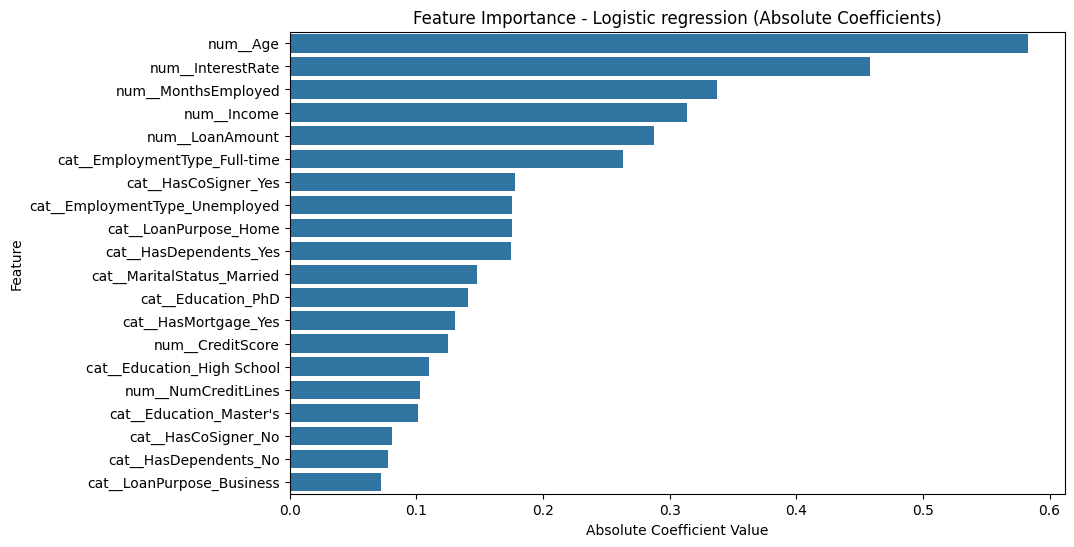

In [ ]:
logistic_model = best_log_model.named_steps['model']
preprocessor_fit = best_log_model.named_steps['preprocessor']

# Get the feature names generated by the preprocessor
transformed_feature_names = preprocessor_fit.get_feature_names_out()

# Get the coefficients from the Logistic Regression model
# For binary classification, coef_ is a 2D array, so we take the first row [0]
importances = logistic_model.coef_[0]

# Create DataFrame for feature importance using absolute values of coefficients
feature_importance = pd.DataFrame({
    'Feature': transformed_feature_names,
    'Importance': np.abs(importances) # Using absolute values for magnitude of importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance.head(20), x='Importance', y='Feature') # Display top N features for better readability

plt.title("Feature Importance - Logistic regression (Absolute Coefficients)")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.show()

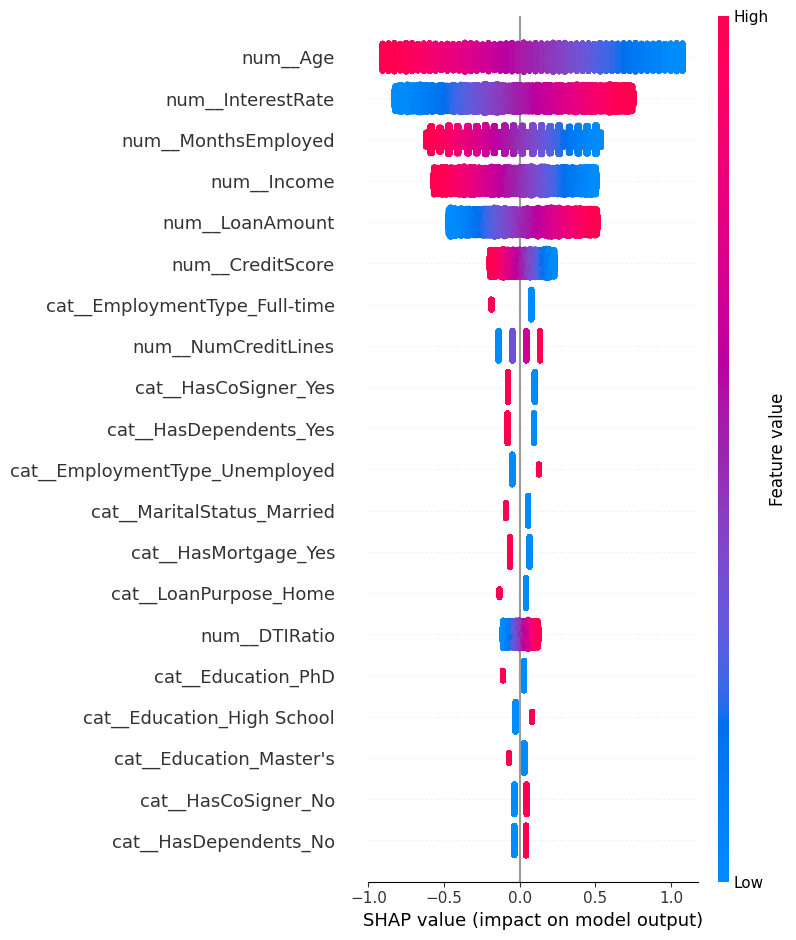

In [ ]:
# Extract the Logistic Regression model and preprocessor from the pipeline
logistic_model = best_log_model.named_steps['model']
preprocessor_fit = best_log_model.named_steps['preprocessor']

# Preprocess x_test using the pipeline's preprocessor
x_test_preprocessed = preprocessor_fit.transform(x_test)

# Get the feature names after preprocessing
transformed_feature_names = preprocessor_fit.get_feature_names_out()

# Create explainer for linear models using the full preprocessed dataset as background
# Set feature_perturbation='correlation_dependent' and pass x_test_preprocessed as masker
# This implicitly uses all samples in x_test_preprocessed as background
explainer = shap.LinearExplainer(logistic_model, x_test_preprocessed, feature_perturbation='correlation_dependent')

# Calculate SHAP values
shap_values = explainer.shap_values(x_test_preprocessed)

# Summary plot
shap.summary_plot(shap_values, x_test_preprocessed, feature_names=transformed_feature_names)

In [ ]:
import joblib

joblib.dump(pipeline, "loan_pipeline.pkl")

['loan_pipeline.pkl']

In [ ]:
import joblib

joblib.dump(best_log_model, "loan_pipeline_log.pkl")

['loan_pipeline_log.pkl']

In [ ]:
from google.colab import files
files.download("loan_pipeline_log.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1
